# Text EDA

In [1]:
import colorsys
import emoji
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import seaborn as sns
import spacy
import warnings
from collections import Counter
from matplotlib.patches import Patch
from matplotlib_venn import venn2
from tqdm import tqdm
from wordcloud import WordCloud

## Setup
In this section, we set up the environment by importing necessary libraries, loading configuration variables, and reading the main dataset into a pandas DataFrame for further analysis.

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# Load paths from .env file
data_dir = os.getenv("DATA_DIR")
images_dir = os.getenv("IMAGES_DIR")

# Load the unified TSV file
annotations_file = os.path.join(data_dir, "annotations.tsv")

In [4]:
df = pd.read_csv(annotations_file, sep="\t")

## TASK 1: Informative vs. Not Informative
In this section, we explore the distribution and characteristics of tweets labeled as `informative` versus `not informative`. We provide example tweets from each class, analyze the number of total and unique tweets per class, and visualize differences in tweet length, word usage, and other linguistic features. This helps us understand the textual patterns that distinguish informative crisis-related tweets from non-informative ones.

### Examples

In [5]:
# Show an example of an "informative" tweet text
informative_example = df[df["text_info"] == "informative"]["tweet_text"].iloc[10]
print("Example of an 'informative' tweet:")
print(informative_example)

print("\n" + "-"*80 + "\n")

# Show an example of a "not informative" tweet text
not_informative_example = df[df["text_info"] == "not_informative"]["tweet_text"].iloc[10]
print("Example of a 'not informative' tweet:")
print(not_informative_example)

Example of an 'informative' tweet:
RT @FoxNews: Southern California fire shrouds Disneyland Anaheim in dramatic, smoky skies https://t.co/nNxpY2kSmS https://t.co/6ripQFkIVh

--------------------------------------------------------------------------------

Example of a 'not informative' tweet:
Playing with my new friend, Chai. She's a California fire evacuee starting with us for a few days. I â¤ï¸ her! https://t.co/Z5PmkUyUJ5


### Tweet distribution

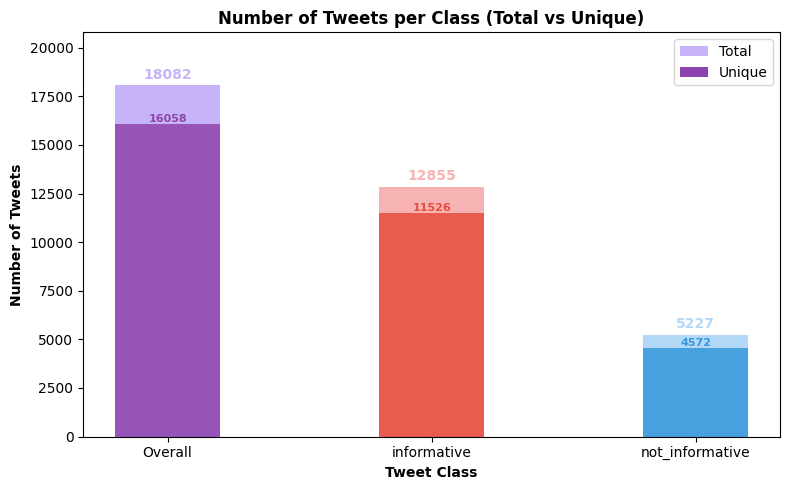

In [6]:
# Count total and unique tweets per class, including Overall
tweet_counts = [
    ("Overall", len(df)),
    ("informative", (df["text_info"] == "informative").sum()),
    ("not_informative", (df["text_info"] == "not_informative").sum())
]
unique_tweet_counts = [
    ("Overall", df["tweet_text"].nunique()),
    ("informative", df[df["text_info"] == "informative"]["tweet_text"].nunique()),
    ("not_informative", df[df["text_info"] == "not_informative"]["tweet_text"].nunique())
]

df_counts = pd.DataFrame(tweet_counts, columns=["Class", "Total"])
df_counts["Unique"] = [count for _, count in unique_tweet_counts]

# Plot grouped bars: total (background), unique (foreground, accent color)
colors = {
    "not_informative": ("#b3d8f7", "#3498db"),  # (total, unique)
    "informative": ("#f7b3b3", "#e74c3c"),
    "Overall": ("#c7b3f7", "#8e44ad")
}

plt.figure(figsize=(8, 5))
bar_width = 0.4
x = range(len(df_counts))

# Plot total bars (background)
for i, cls in enumerate(df_counts["Class"]):
    plt.bar(i, df_counts.loc[i, "Total"], width=bar_width, color=colors[cls][0], zorder=1)

# Plot unique bars (foreground, same width, slightly shifted up for visibility)
for i, cls in enumerate(df_counts["Class"]):
    plt.bar(i, df_counts.loc[i, "Unique"], width=bar_width, color=colors[cls][1], alpha=0.85, zorder=2)

# Add count labels
for i, row in df_counts.iterrows():
    plt.text(i, row["Total"] + max(df_counts["Total"])*0.01, f'{row["Total"]}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=colors[row["Class"]][0],zorder=3)
    plt.text(i, row["Unique"], f'{row["Unique"]}', ha='center', va='bottom', fontsize=8, fontweight='bold', color=colors[row["Class"]][1], zorder=3)

plt.xticks(x, df_counts["Class"])
plt.title("Number of Tweets per Class (Total vs Unique)", fontweight='bold')
plt.xlabel("Tweet Class", fontweight='bold')
plt.ylabel("Number of Tweets", fontweight='bold')
plt.ylim(top=max(df_counts["Total"]) * 1.15)  # Add space above the tallest bar

# Custom legend
legend_elements = [
    Patch(facecolor=colors["Overall"][0], label='Total'),
    Patch(facecolor=colors["Overall"][1], label='Unique')
]
plt.legend(handles=legend_elements)

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "task-1_class_distribution_barplots.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

The number of unique tweets is lower than the total for each class, indicating some tweets are repeated. This is due to the fact that one tweet may contain more than one attached image, resulting in duplicate entries in the dataset for the `tweet_text` feature.

The dataset is dominated by informative tweets, and both classes contain repeated content, but the diversity (unique/total ratio) is higher for "informative" tweets.

### Tweet length distribution

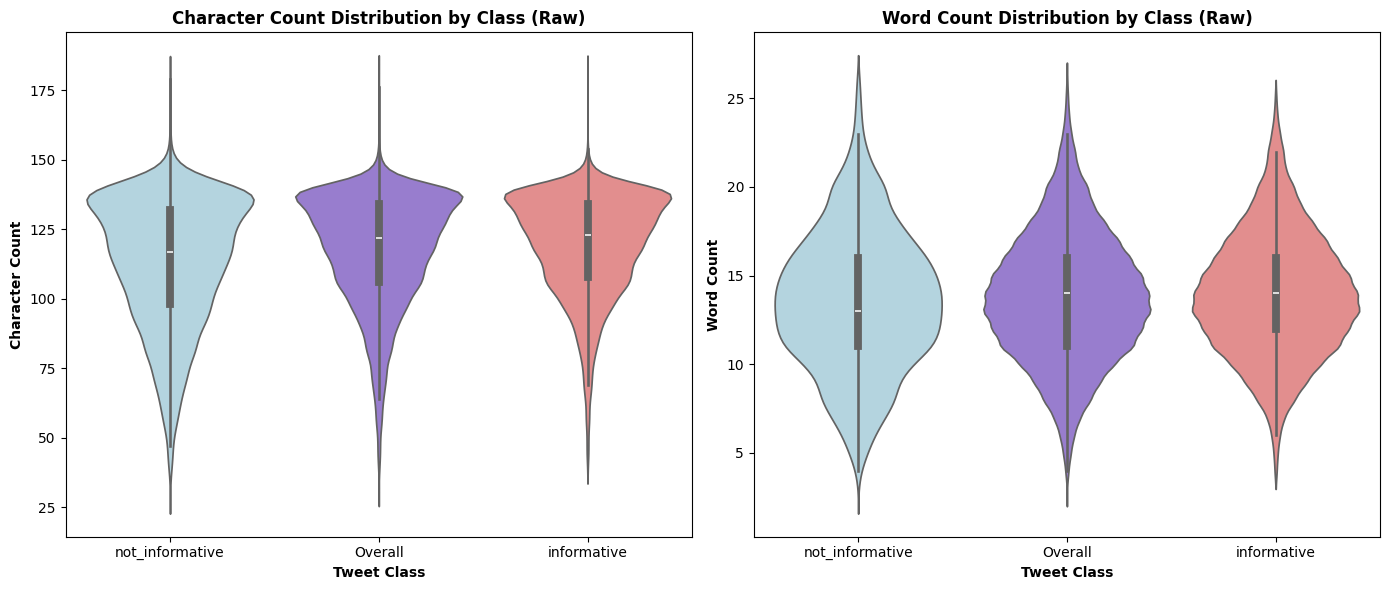

Average tweet lengths by class:
                 char_count  word_count
text_info                              
informative      119.350370   13.910152
not_informative  113.050698   13.549837

Overall averages:
   char_count  word_count
0  117.529311   13.805995


In [7]:
label_column = "text_info"

# Compute length features
df["char_count"] = df["tweet_text"].astype(str).apply(len)
df["word_count"] = df["tweet_text"].astype(str).apply(lambda x: len(x.split()))

# Create a copy for overall distribution
df_overall = df.copy()
df_overall[label_column] = "Overall"

# Combine original and overall data
df_combined = pd.concat([df, df_overall], ignore_index=True)

# Define custom order
label_order = ["not_informative", "Overall", "informative"] if "informative" in df[label_column].unique() else sorted(df[label_column].unique()) + ["Overall"]

# Plot
plt.figure(figsize=(14, 6))

# Character count violin
plt.subplot(1, 2, 1)
sns.violinplot(data=df_combined, x=label_column, y="char_count",
               order=label_order,
               palette={"not_informative": "lightblue", "informative": "lightcoral", "Overall": "mediumpurple"},
               hue=label_column,
               legend=False)
plt.title("Character Count Distribution by Class (Raw)", fontweight='bold')
plt.xlabel("Tweet Class", fontweight='bold')
plt.ylabel("Character Count", fontweight='bold')

# Word count violin
plt.subplot(1, 2, 2)
sns.violinplot(data=df_combined, x=label_column, y="word_count",
               order=label_order,
               palette={"not_informative": "lightblue", "informative": "lightcoral", "Overall": "mediumpurple"},
               hue=label_column,
               legend=False)
plt.title("Word Count Distribution by Class (Raw)", fontweight='bold')
plt.xlabel("Tweet Class", fontweight='bold')
plt.ylabel("Word Count", fontweight='bold')

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "task-1_raw_tweet_length_violinplots.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

# Print averages
print("Average tweet lengths by class:")
print(df.groupby(label_column)[["char_count", "word_count"]].mean())
print("\nOverall averages:")
print(df[["char_count", "word_count"]].mean().to_frame().T)



The plot displays the distribution of tweet lengths (in both characters and words) for each class: "informative", "not informative", and "Overall". Each class is represented as a violin plot, showing the density and spread of tweet lengths.

Informative tweets tend to be slightly longer, both in character and word count, compared to not informative tweets, which have a tighter distribution.

The difference in length, even so small, suggests that informative tweets provide more detailed content, while not informative tweets are more concise or generic.
 
Tweet length could be a distinguishing feature between informative and not informative tweets. Longer tweets are more likely to be informative, which can be useful for feature engineering in classification tasks.

### Most frequent words (Raw)

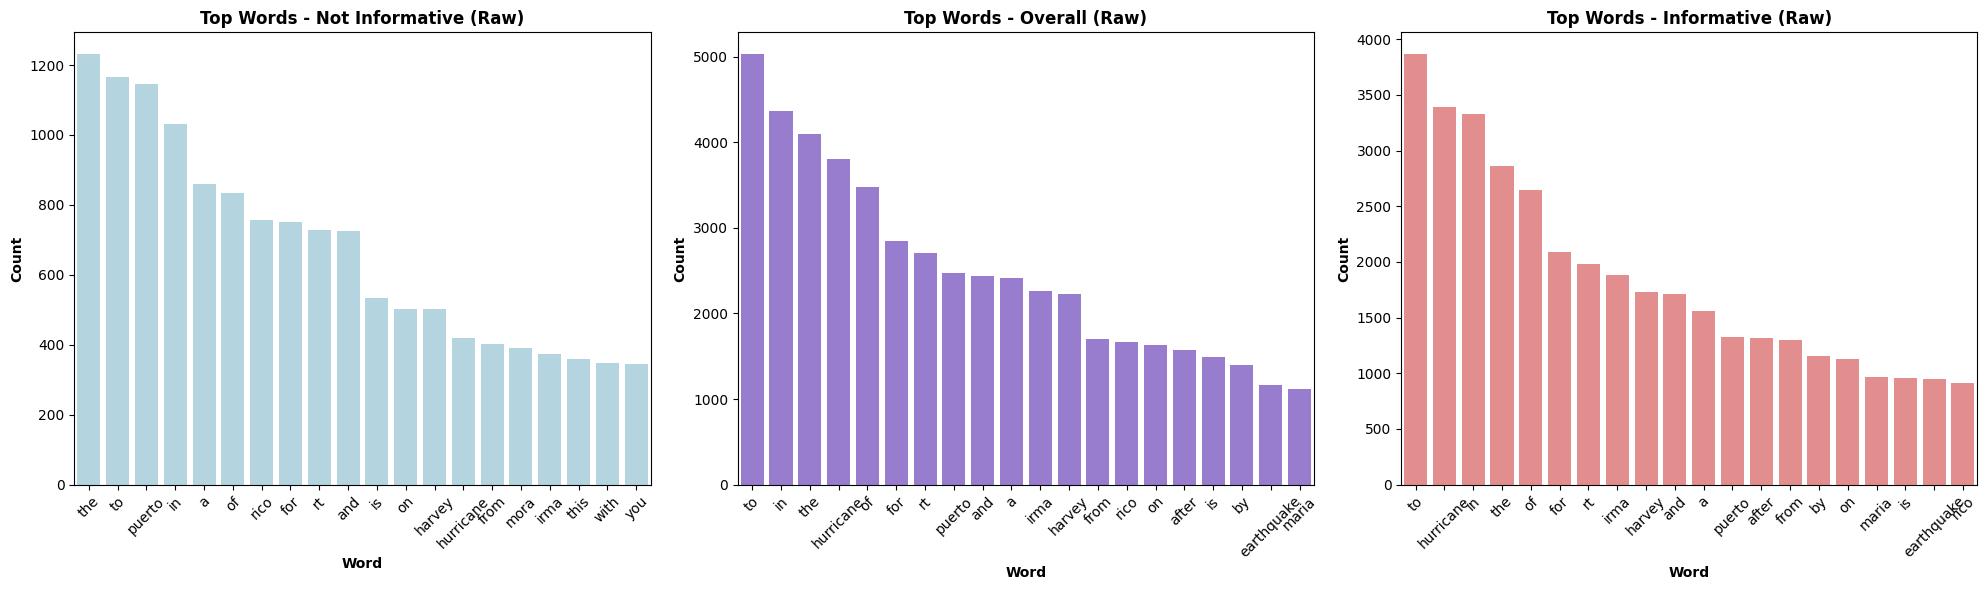

In [8]:
label_column = "text_info"
text_column = "tweet_text"

# Function to get top words from texts
def get_top_words_raw(texts, n=None):
    words = " ".join(texts.dropna().astype(str)).split()
    filtered = [w.lower() for w in words if w.isalpha()]
    counter = Counter(filtered)
    if n is not None:
        return counter.most_common(n)
    return counter.most_common()  # All words, sorted by frequency

# Get all words (no n), useful for word clouds
all_words_informative = get_top_words_raw(df[df[label_column] == "informative"][text_column])
all_words_not_informative = get_top_words_raw(df[df[label_column] == "not_informative"][text_column])
all_words_overall = get_top_words_raw(df[text_column])

freq_informative = dict(all_words_informative)
freq_not_informative = dict(all_words_not_informative)
freq_overall = dict(all_words_overall)

# For barplots: only top 20
top_words_informative_raw = all_words_informative[:20]
top_words_not_informative_raw = all_words_not_informative[:20]
top_words_overall_raw = all_words_overall[:20]

df_informative_raw = pd.DataFrame(top_words_informative_raw, columns=["word", "count"])
df_not_informative_raw = pd.DataFrame(top_words_not_informative_raw, columns=["word", "count"])
df_overall_raw = pd.DataFrame(top_words_overall_raw, columns=["word", "count"])

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
sns.barplot(data=df_not_informative_raw, x="word", y="count", ax=axes[0], color="lightblue")
axes[0].set_title("Top Words - Not Informative (Raw)", fontweight='bold')
axes[0].set_xlabel("Word", fontweight='bold')
axes[0].set_ylabel("Count", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
sns.barplot(data=df_overall_raw, x="word", y="count", ax=axes[1], color="mediumpurple")
axes[1].set_title("Top Words - Overall (Raw)", fontweight='bold')
axes[1].set_xlabel("Word", fontweight='bold')
axes[1].set_ylabel("Count", fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
sns.barplot(data=df_informative_raw, x="word", y="count", ax=axes[2], color="lightcoral")
axes[2].set_title("Top Words - Informative (Raw)", fontweight='bold')
axes[2].set_xlabel("Word", fontweight='bold')
axes[2].set_ylabel("Count", fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "task-1_raw_top_words_barplots.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

The Plot displays the 20 most frequent words in each tweet class.

Common disaster-related terms such as "hurricane", "harvey", "irma", "puerto", "rico", and "california" are prominent across all classes, reflecting the dataset's crisis context.

Given that no preprocessing was applied, stopwords dominate the top-20 and thus not highlighting the linguistic differences between informative and non-informative tweets.

### Word clouds

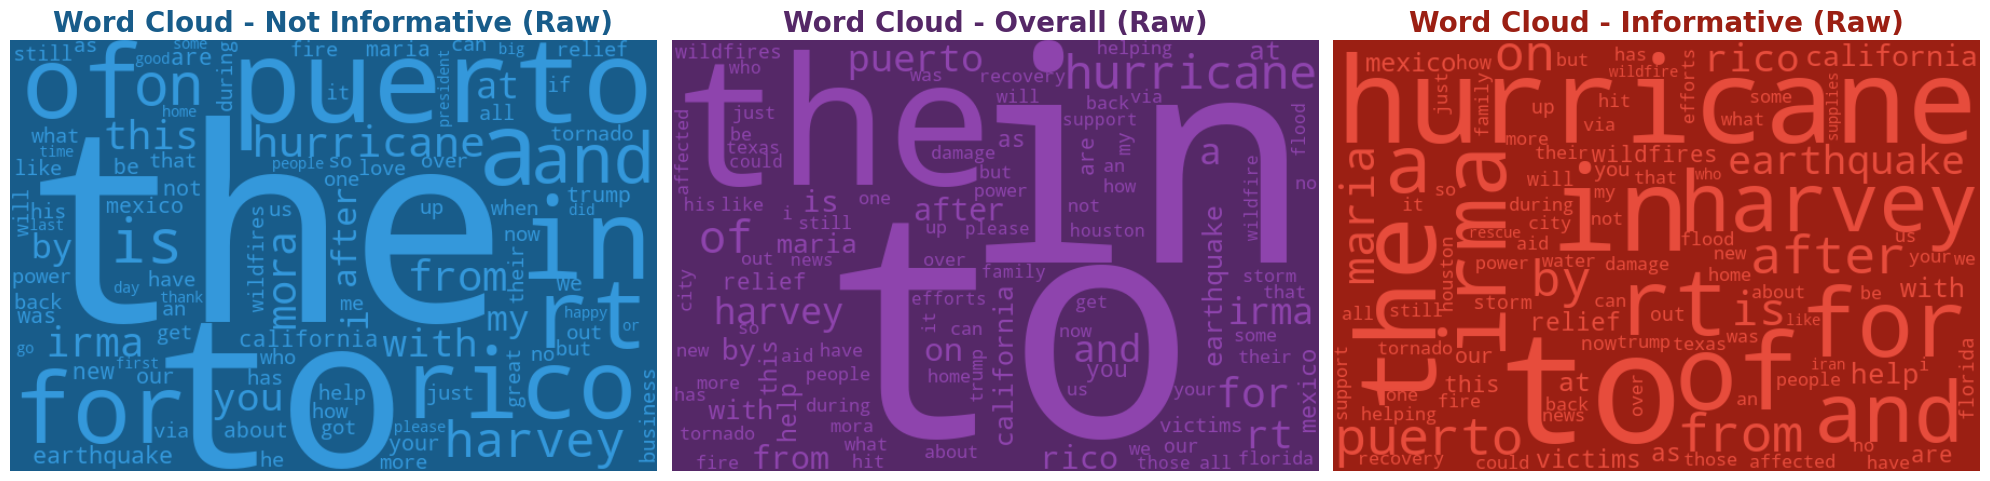

In [9]:
def darken_color(rgb, factor=0.6):
    """Darken an RGB color by a given factor (0-1)."""
    h, l, s = colorsys.rgb_to_hls(*rgb)
    l = max(0, l * factor)
    return colorsys.hls_to_rgb(h, l, s)

info_colors = {
    "not_informative": (52/255, 152/255, 219/255),   # #3498db
    "Overall": (142/255, 68/255, 173/255),           # #8e44ad
    "informative": (231/255, 76/255, 60/255)         # #e74c3c
}

def rgb_to_hex(rgb):
    return '#%02x%02x%02x' % tuple(int(255 * c) for c in rgb)

fig_wc, axes_wc = plt.subplots(1, 3, figsize=(20, 7))

# Not Informative
rgb = info_colors["not_informative"]
dark_rgb = darken_color(rgb)
wc_not_inf = WordCloud(
    width=600, height=400,
    background_color=rgb_to_hex(dark_rgb),
    colormap=None,
    color_func=lambda *args, **kwargs: rgb_to_hex(rgb),
    max_words=100
).generate_from_frequencies(freq_not_informative)
axes_wc[0].imshow(wc_not_inf, interpolation='bilinear')
axes_wc[0].set_title('Word Cloud - Not Informative (Raw)', fontsize=20, fontweight='bold', color=rgb_to_hex(dark_rgb))
axes_wc[0].axis('off')

# Overall
rgb = info_colors["Overall"]
dark_rgb = darken_color(rgb)
wc_overall = WordCloud(
    width=600, height=400,
    background_color=rgb_to_hex(dark_rgb),
    colormap=None,
    color_func=lambda *args, **kwargs: rgb_to_hex(rgb),
    max_words=100
).generate_from_frequencies(freq_overall)
axes_wc[1].imshow(wc_overall, interpolation='bilinear')
axes_wc[1].set_title('Word Cloud - Overall (Raw)', fontsize=20, fontweight='bold', color=rgb_to_hex(dark_rgb))
axes_wc[1].axis('off')

# Informative
rgb = info_colors["informative"]
dark_rgb = darken_color(rgb)
wc_inf = WordCloud(
    width=600, height=400,
    background_color=rgb_to_hex(dark_rgb),
    colormap=None,
    color_func=lambda *args, **kwargs: rgb_to_hex(rgb),
    max_words=100
).generate_from_frequencies(freq_informative)
axes_wc[2].imshow(wc_inf, interpolation='bilinear')
axes_wc[2].set_title('Word Cloud - Informative (Raw)', fontsize=20, fontweight='bold', color=rgb_to_hex(dark_rgb))
axes_wc[2].axis('off')

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "task-1_raw_wordclouds.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

The plots above display word clouds for each tweet class: "Not Informative", "Overall", and "Informative". Each word cloud visualizes the most frequent words in the raw tweet texts, with word size proportional to frequency.

The color scheme distinguishes each class, and the background color is a darker shade of the main class color for better contrast.

Due to lack of preprocessing, common stopwords (e.g., "the", "to", "in") are also highly visible, especially in the "Overall" and "Not Informative" classes.

Overall, the word clouds provide a quick visual summary of dominant vocabulary in each class, but further preprocessing (e.g., stopword removal) would help reveal more meaningful differences.


## TASK 2: Humanitarian Categories
In this section, we analyze the humanitarian categories assigned to tweets in the dataset. Each tweet is labeled with one of several humanitarian classes (belonging to the `text_human` feature), which provide more granular information about the type of crisis-related content.

The classes are the following:

- **Affected individuals**: Tweets about people directly impacted by the crisis.
- **Infrastructure and utilities damage**: Tweets describing damage to buildings, roads, power lines, or other infrastructure.
- **Injured or dead people**: Tweets reporting injuries or fatalities.
- **Missing or found people**: Tweets about people who are missing or have been found.
- **Rescue, volunteering, or donation effort**: Tweets related to rescue operations, volunteer activities, or donation campaigns.
- **Other relevant information**: Tweets containing other crisis-relevant details not covered by the above categories.
- **Vehicle damage**: Tweets specifically mentioning damage to vehicles.
- **Not humanitarian**: Tweets that do not provide humanitarian information.

We will explore the distribution of tweets across these classes, provide example tweets for each, and visualize differences in tweet length and word usage by humanitarian category. This helps us understand the diversity and focus of crisis-related information shared on social media.

### Examples

In [10]:
# Mapping from class code to full name
class_name_map = {
	"affected_individuals": "Affected individuals",
	"infrastructure_and_utility_damage": "Infrastructure and utilities damage",
	"injured_or_dead_people": "Injured or dead people",
	"missing_or_found_people": "Missing or found people",
	"rescue_volunteering_or_donation_effort": "Rescue, volunteering, or donation effort",
	"other_relevant_information": "Other relevant information",
	"not_humanitarian": "Not humanitarian",
	"vehicle_damage": "Vehicle damage"
}

# Show an example tweet for each humanitarian class in text_human
for cls in sorted(df["text_human"].dropna().unique()):
	example = df[df["text_human"] == cls]["tweet_text"].iloc[0]
	print(f"Class: {class_name_map.get(cls, cls)}")
	print(example)
	print("-" * 80)

Class: Affected individuals
I just had to evacuate my home in California due to the wildfire. Obviously, I took the essentials. https://t.co/wUBzDS4xFA
--------------------------------------------------------------------------------
Class: Infrastructure and utilities damage
PHOTOS: Deadly wildfires rage in California https://t.co/td9xT3vXOL https://t.co/OimwAncLew
--------------------------------------------------------------------------------
Class: Injured or dead people
Mass Evacuations in California as Wildfires Kill at Least 10 https://t.co/gyoKFWZuMB #CaliforniaWildfires https://t.co/KEFtjITetK
--------------------------------------------------------------------------------
Class: Missing or found people
More than 100 missing persons reports made in CaliforniaÂ wildfires https://t.co/614UWl30MO https://t.co/CBuNhzQ5xf
--------------------------------------------------------------------------------
Class: Not humanitarian
California wildfire. á½¡4 https://t.co/a8oD5rkDdI
--------

### Tweet distribution

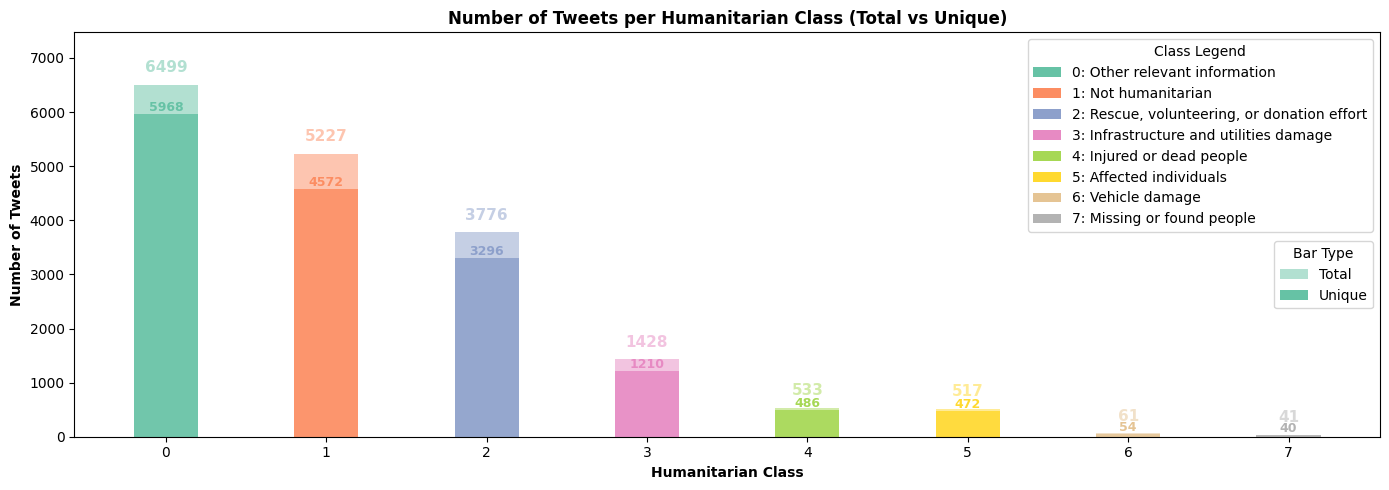

In [11]:
# Count total and unique tweets per humanitarian class (NO Overall)
human_label = "text_human"
tweet_counts_human = [
    (cls, (df[human_label] == cls).sum())
    for cls in sorted(df[human_label].dropna().unique())
]
unique_tweet_counts_human = [
    (cls, df[df[human_label] == cls]["tweet_text"].nunique())
    for cls in sorted(df[human_label].dropna().unique())
]

df_counts_human = pd.DataFrame(tweet_counts_human, columns=["Class", "Total"])
df_counts_human["Unique"] = [count for _, count in unique_tweet_counts_human]

# Sort by ascending total
df_counts_human = df_counts_human.sort_values(by="Total", ascending=False).reset_index(drop=True)

# Assign colors (use a palette for classes)
palette = sns.color_palette("Set2", n_colors=len(df_counts_human))
colors_human = {cls: (tuple([*col, 0.5]), tuple(col)) for cls, col in zip(df_counts_human["Class"], palette)}

# Shorten x-tick labels for clarity (numbers for classes)
short_labels = [str(i) for i in range(len(df_counts_human))]

plt.figure(figsize=(max(14, len(df_counts_human)*1.2), 5))
bar_width = 0.4
x = range(len(df_counts_human))

# Plot total bars (background)
for i, cls in enumerate(df_counts_human["Class"]):
	plt.bar(i, df_counts_human.loc[i, "Total"], width=bar_width, color=colors_human[cls][0], zorder=1)

# Plot unique bars (foreground, same width)
for i, cls in enumerate(df_counts_human["Class"]):
	plt.bar(i, df_counts_human.loc[i, "Unique"], width=bar_width, color=colors_human[cls][1], alpha=0.85, zorder=2)

# Add count labels
for i, row in df_counts_human.iterrows():
	plt.text(i, row["Total"] + max(df_counts_human["Total"])*0.028, f'{row["Total"]}', ha='center', va='bottom', fontsize=11, fontweight='bold', color=colors_human[row["Class"]][0], zorder=3)
	plt.text(i, row["Unique"], f'{row["Unique"]}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=colors_human[row["Class"]][1], zorder=3)

plt.xticks(x, short_labels, ha='center')
plt.title("Number of Tweets per Humanitarian Class (Total vs Unique)", fontweight='bold')
plt.xlabel("Humanitarian Class", fontweight='bold')
plt.ylabel("Number of Tweets", fontweight='bold')
plt.ylim(top=max(df_counts_human["Total"]) * 1.15)

# Custom legend for bar types (Total/Unique)
legend_elements = [
	Patch(facecolor=colors_human["other_relevant_information"][0], label='Total'),
	Patch(facecolor=colors_human["other_relevant_information"][1], label='Unique')
]

# Add a second legend for class names/colors
class_legend_elements = [
	Patch(facecolor=colors_human[cls][1], label=f"{short_labels[i]}: {class_name_map.get(cls, cls)}")
	for i, cls in enumerate(df_counts_human["Class"])
]

# Place both legends in the top right corner
first_legend = plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 0.50), title="Bar Type")
plt.gca().add_artist(first_legend)
plt.legend(handles=class_legend_elements, loc='upper right', bbox_to_anchor=(1, 1), title="Class Legend")

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "task-2_class_distribution_barplots.png")
plt.savefig(output_path, bbox_inches='tight')

plt.tight_layout()
plt.show()

The plot above shows the distribution of tweets across the different humanitarian categories, as defined by the `text_human` label. For each class, two bars are displayed: one for the total number of tweets and one for the number of unique tweets (i.e., tweets with distinct text).

**"Other relevant information"** and **"Rescue, volunteering, or donation effort"** are the most frequent categories, indicating that a large portion of tweets provide general crisis updates or information about relief efforts.

**"Not humanitarian"** is also a substantial class, reflecting many tweets that do not provide specific humanitarian information.

Categories such as **"Missing or found people"** and **"Vehicle damage"** have the fewest tweets, suggesting these topics are less commonly discussed. With such a little number of samples availables it might be difficult to work with these classes.

The diversity (unique/total ratio) varies by class, with some categories showing more repetition than others. This distribution highlights the imbalance among humanitarian categories and suggests that certain types of crisis information are much more prevalent on social media.

### Tweet length distribution

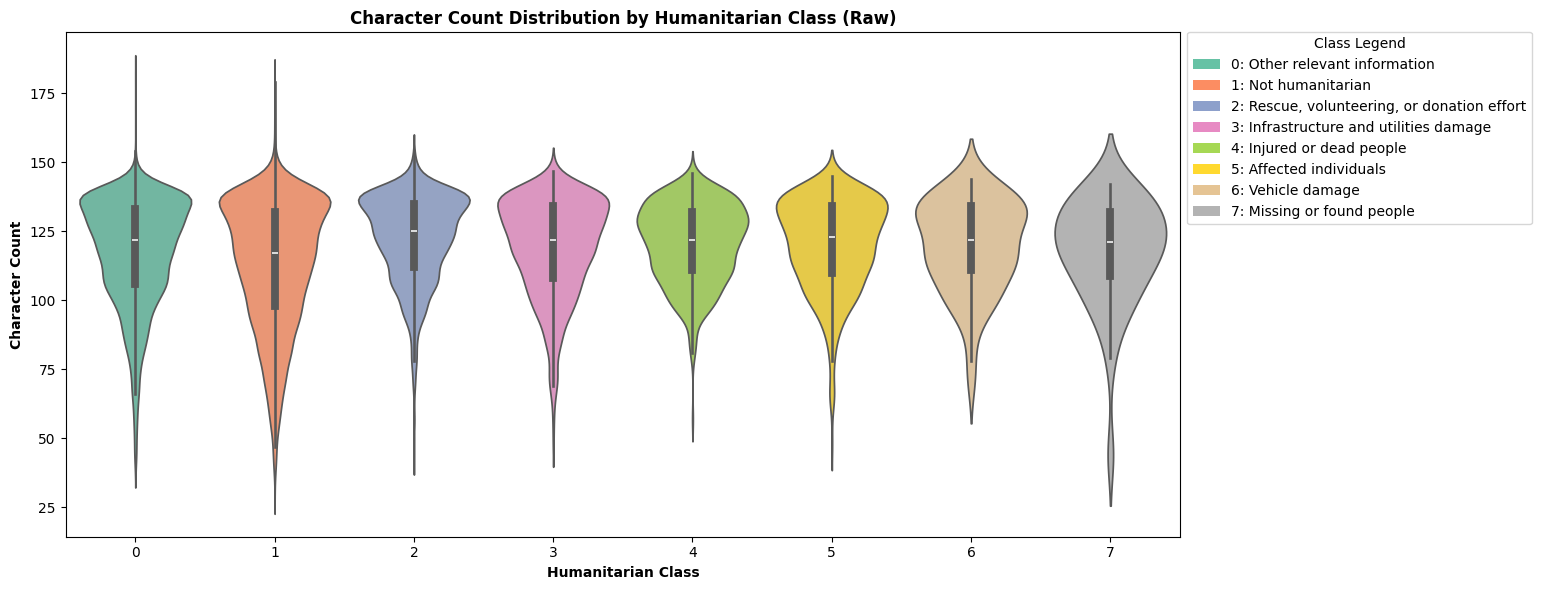

Average character count by humanitarian class:
text_human
other_relevant_information                117.444838
not_humanitarian                          113.050698
rescue_volunteering_or_donation_effort    122.487818
infrastructure_and_utility_damage         119.116246
injured_or_dead_people                    120.474672
affected_individuals                      119.969052
vehicle_damage                            119.737705
missing_or_found_people                   117.609756
Name: char_count, dtype: float64


In [12]:
label_column = "text_human"

# Compute character count if not already present
if "char_count" not in df.columns:
    df["char_count"] = df["tweet_text"].astype(str).apply(len)

# Use the same class order and colors as in the barplot
class_order = list(df_counts_human["Class"])
short_labels = [str(i) for i in range(len(class_order))]

warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(max(12, len(class_order)*1.2), 6))
sns.violinplot(
    data=df,
    x=label_column,
    y="char_count",
    order=class_order,
    palette=[colors_human[cls][1] for cls in class_order]
)

plt.title("Character Count Distribution by Humanitarian Class (Raw)", fontweight='bold')
plt.xlabel("Humanitarian Class", fontweight='bold')
plt.ylabel("Character Count", fontweight='bold')
plt.xticks(ticks=range(len(class_order)), labels=short_labels, ha='center')
plt.tight_layout()

# Add legend for class names/colors
class_legend_elements = [
    Patch(facecolor=colors_human[cls][1], label=f"{short_labels[i]}: {class_name_map.get(cls, cls)}")
    for i, cls in enumerate(class_order)
]
plt.legend(handles=class_legend_elements, loc='upper left', bbox_to_anchor=(1, 1.015), title="Class Legend")

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "task-2_raw_char_count_violinplot.png")
plt.savefig(output_path, bbox_inches='tight')

plt.show()

# Print average character count for each class
print("Average character count by humanitarian class:")
print(df.groupby(label_column)["char_count"].mean().reindex(class_order))

The plot above shows the distribution of tweet word counts across the different humanitarian categories, as defined by the `text_human` label. Each violin plot represents a humanitarian class, with the width indicating the density of tweets at different word counts.

**"Other relevant information"** and **"Rescue, volunteering, or donation effort"** have the widest distributions, reflecting a large and diverse set of tweets in these categories.

**"Missing or found people"** and **"Vehicle damage"** have narrower distributions, likely due to fewer samples.

Most classes have a similar median word count, but some (like "affected individuals" and "injured or dead people") show slightly longer tweets on average.

The diversity in word count suggests that certain humanitarian categories encourage more detailed reporting, while others are more concise.

Overall, tweet length (in words) varies by humanitarian class, which may be useful for downstream classification or feature engineering.

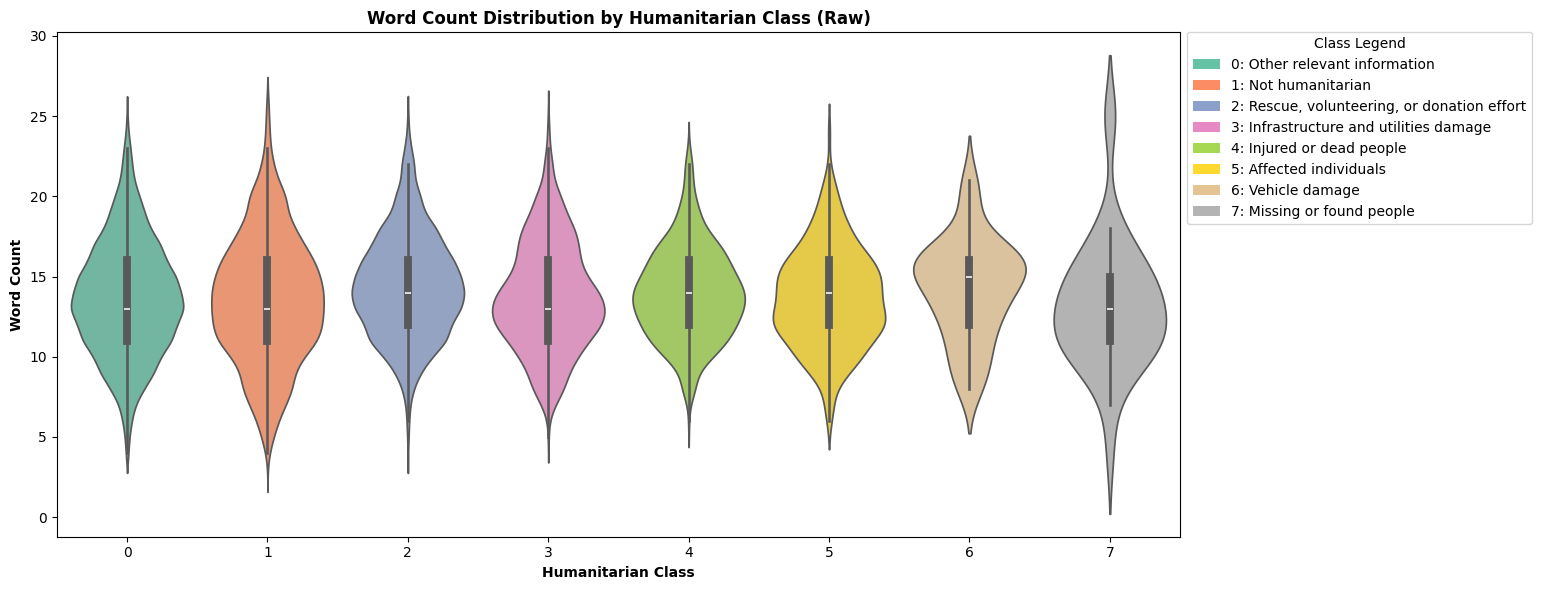

Average word count by humanitarian class:
text_human
other_relevant_information                13.656563
not_humanitarian                          13.549837
rescue_volunteering_or_donation_effort    14.417373
infrastructure_and_utility_damage         13.782213
injured_or_dead_people                    13.966229
affected_individuals                      13.707930
vehicle_damage                            14.245902
missing_or_found_people                   13.170732
Name: word_count, dtype: float64


In [13]:
# Word count distribution by humanitarian class (no Overall, custom colors, legend for class names)
label_column = "text_human"

# Compute word count if not already present
if "word_count" not in df.columns:
	df["word_count"] = df["tweet_text"].astype(str).apply(lambda x: len(x.split()))

# Use the same class order and colors as in the barplot
class_order = list(df_counts_human["Class"])
short_labels = [str(i) for i in range(len(class_order))]

plt.figure(figsize=(max(12, len(class_order)*1.2), 6))
sns.violinplot(
	data=df,
	x=label_column,
	y="word_count",
	order=class_order,
	palette=[colors_human[cls][1] for cls in class_order]
)

plt.title("Word Count Distribution by Humanitarian Class (Raw)", fontweight='bold')
plt.xlabel("Humanitarian Class", fontweight='bold')
plt.ylabel("Word Count", fontweight='bold')
plt.xticks(ticks=range(len(class_order)), labels=short_labels, ha='center')
plt.tight_layout()

# Add legend for class names/colors
class_legend_elements = [
	Patch(facecolor=colors_human[cls][1], label=f"{short_labels[i]}: {class_name_map.get(cls, cls)}")
	for i, cls in enumerate(class_order)
]
plt.legend(handles=class_legend_elements, loc='upper left', bbox_to_anchor=(1, 1.015), title="Class Legend")

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "task-2_raw_word_count_violinplot.png")
plt.savefig(output_path, bbox_inches='tight')

plt.show()

# Print average word count for each class
print("Average word count by humanitarian class:")
print(df.groupby(label_column)["word_count"].mean().reindex(class_order))

The violin plot above illustrates the distribution of tweet word counts for each humanitarian category defined by the `text_human` label. Each violin represents a different class, with the width indicating the density of tweets at various word counts.

The take-aways from this plot are pretty much the same of the previous one.

### Most frequent words (Raw)

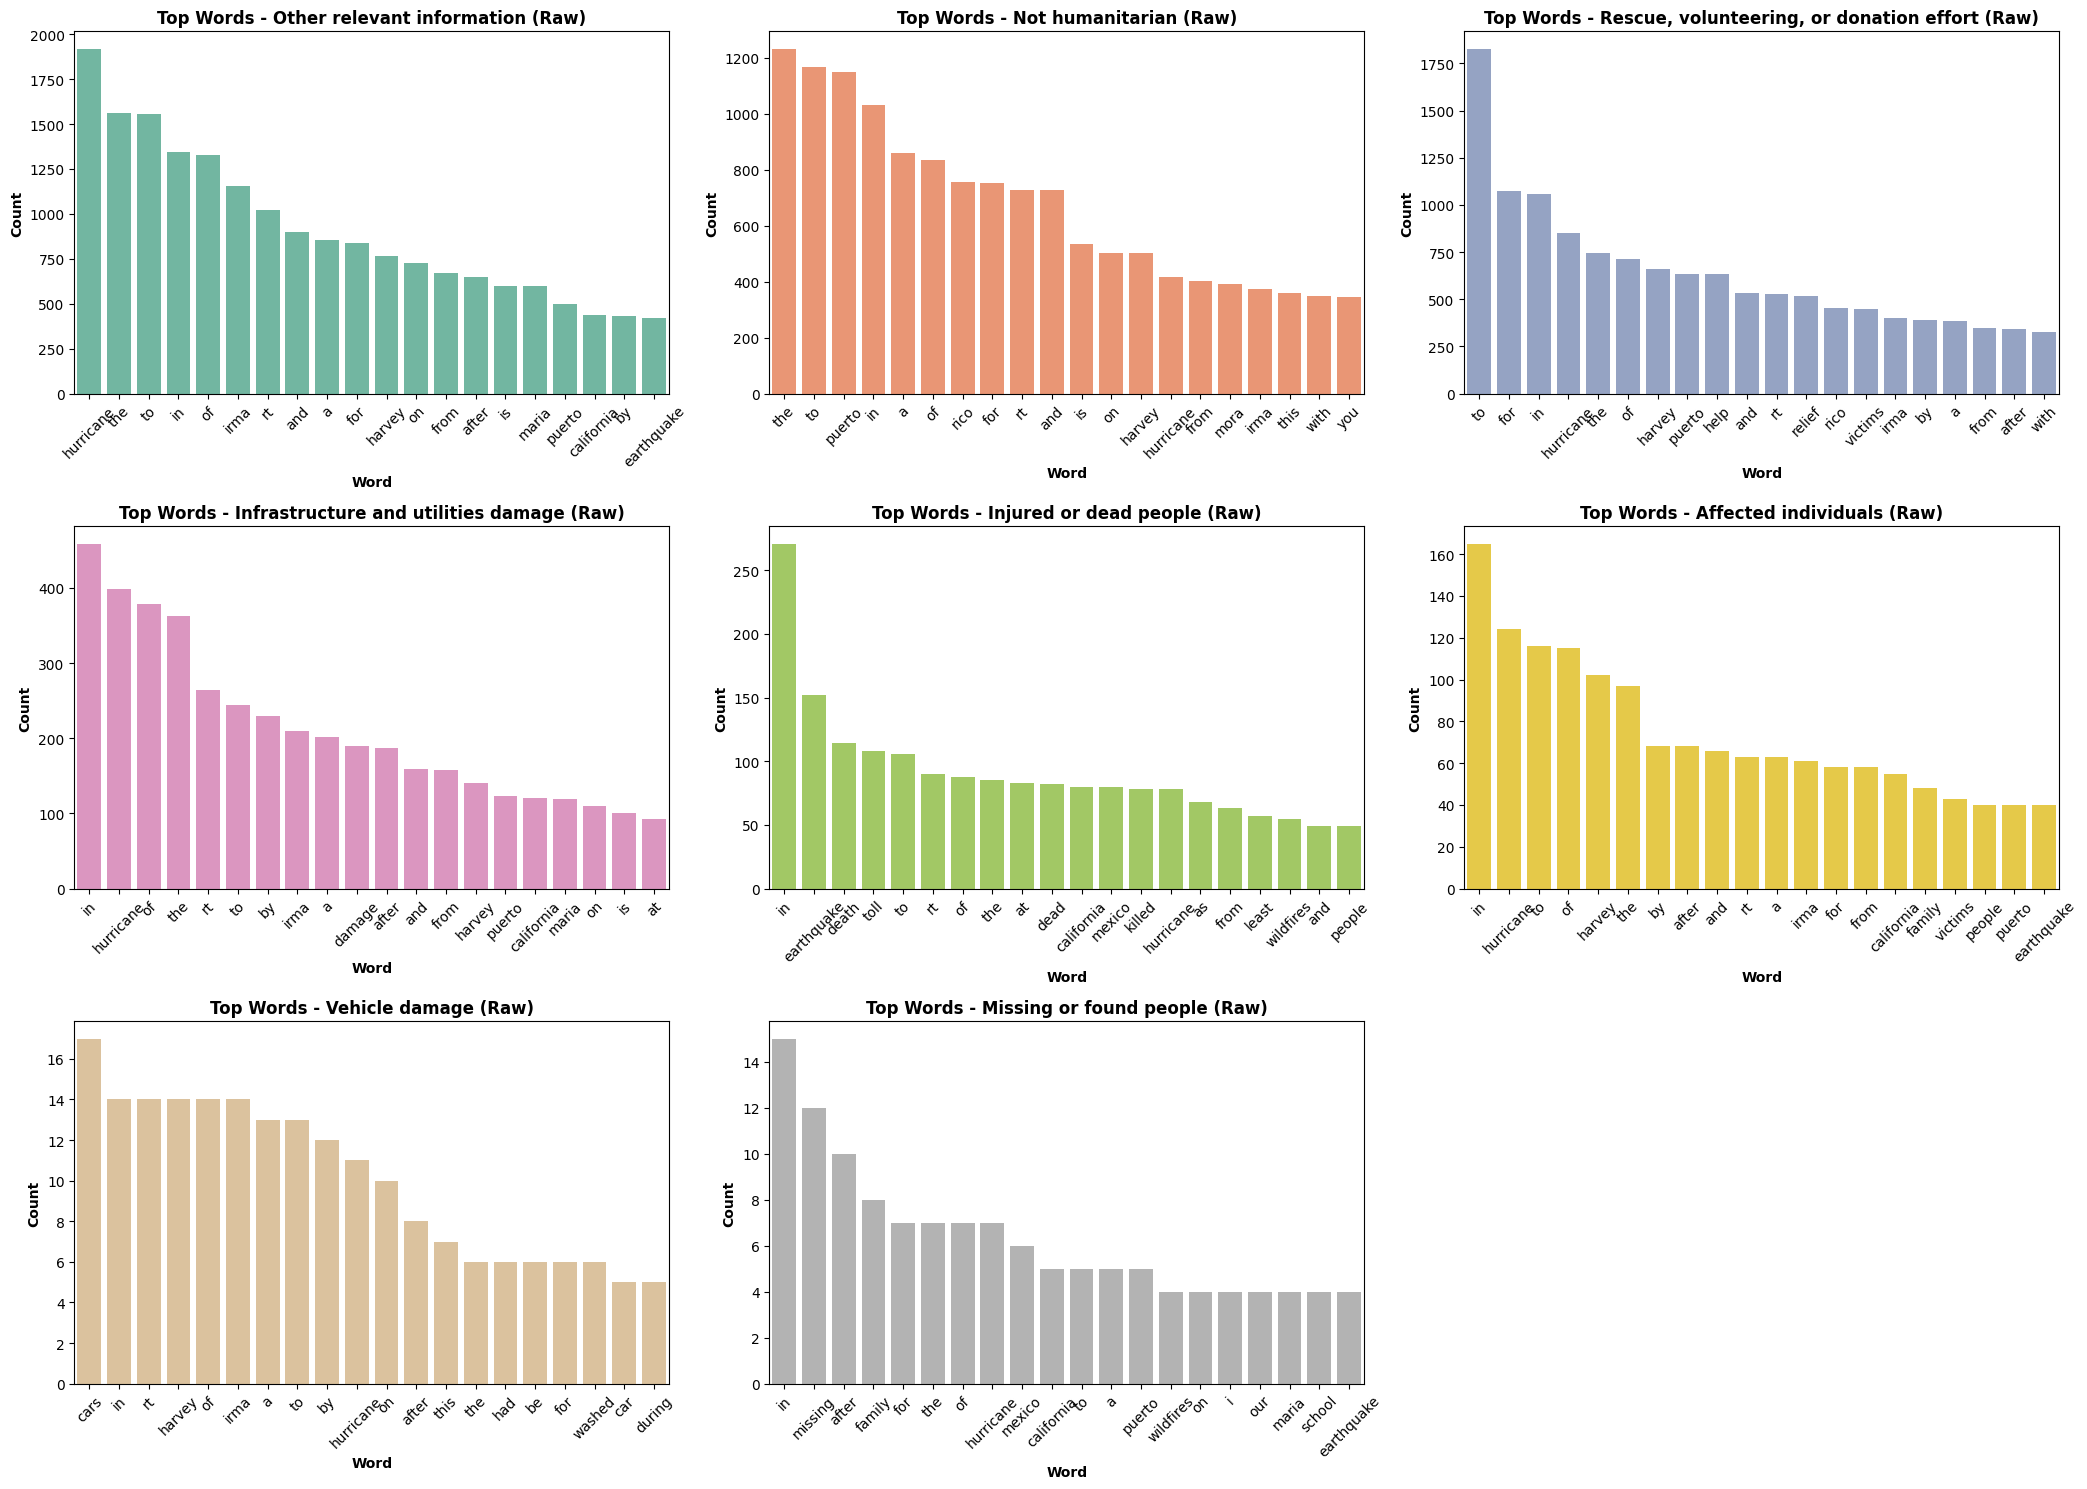

In [14]:
import math
top_n = 20

# Calculate number of rows and columns for subplots
n_classes = len(class_order)
n_cols = 3
n_rows = math.ceil(n_classes / n_cols)

fig_human, axes_human = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 5))
axes_human = axes_human.flatten()

for idx, cls in enumerate(class_order):
	texts = df[df["text_human"] == cls]["tweet_text"]
	words = " ".join(texts.dropna().astype(str)).split()
	filtered = [w.lower() for w in words if w.isalpha()]
	freq = Counter(filtered).most_common(top_n)
	df_top = pd.DataFrame(freq, columns=["word", "count"])
	color = colors_human[cls][1]
	sns.barplot(data=df_top, x="word", y="count", ax=axes_human[idx], color=color)
	axes_human[idx].set_title(f"Top Words - {class_name_map.get(cls, cls)} (Raw)", fontweight='bold')
	axes_human[idx].set_xlabel("Word", fontweight='bold')
	axes_human[idx].set_ylabel("Count", fontweight='bold')
	axes_human[idx].tick_params(axis='x', rotation=45)

# Remove unused axes if any
for j in range(len(class_order), len(axes_human)):
	fig_human.delaxes(axes_human[j])

plt.tight_layout()
output_path = os.path.join(images_dir, "task-2_raw_top_words_barplots.png")
plt.savefig(output_path)
plt.show()

The barplots above display the top 20 most frequent words for each humanitarian class in the dataset (raw text, no preprocessing). Each subplot corresponds to a different humanitarian category, showing the most common words and their counts.

Some classes have distinctive terms that relate to their specific humanitarian focus. For example, `injured_or_dead_people` features words like "dead", "injured", and "killed", while `rescue_volunteering_or_donation_effort` includes "help", "donate", and "support".

Overall, these barplots provide an initial overview of word usage patterns by humanitarian category, but further preprocessing (e.g., stopword removal, lemmatization) would help highlight more meaningful differences between classes.

### Word clouds

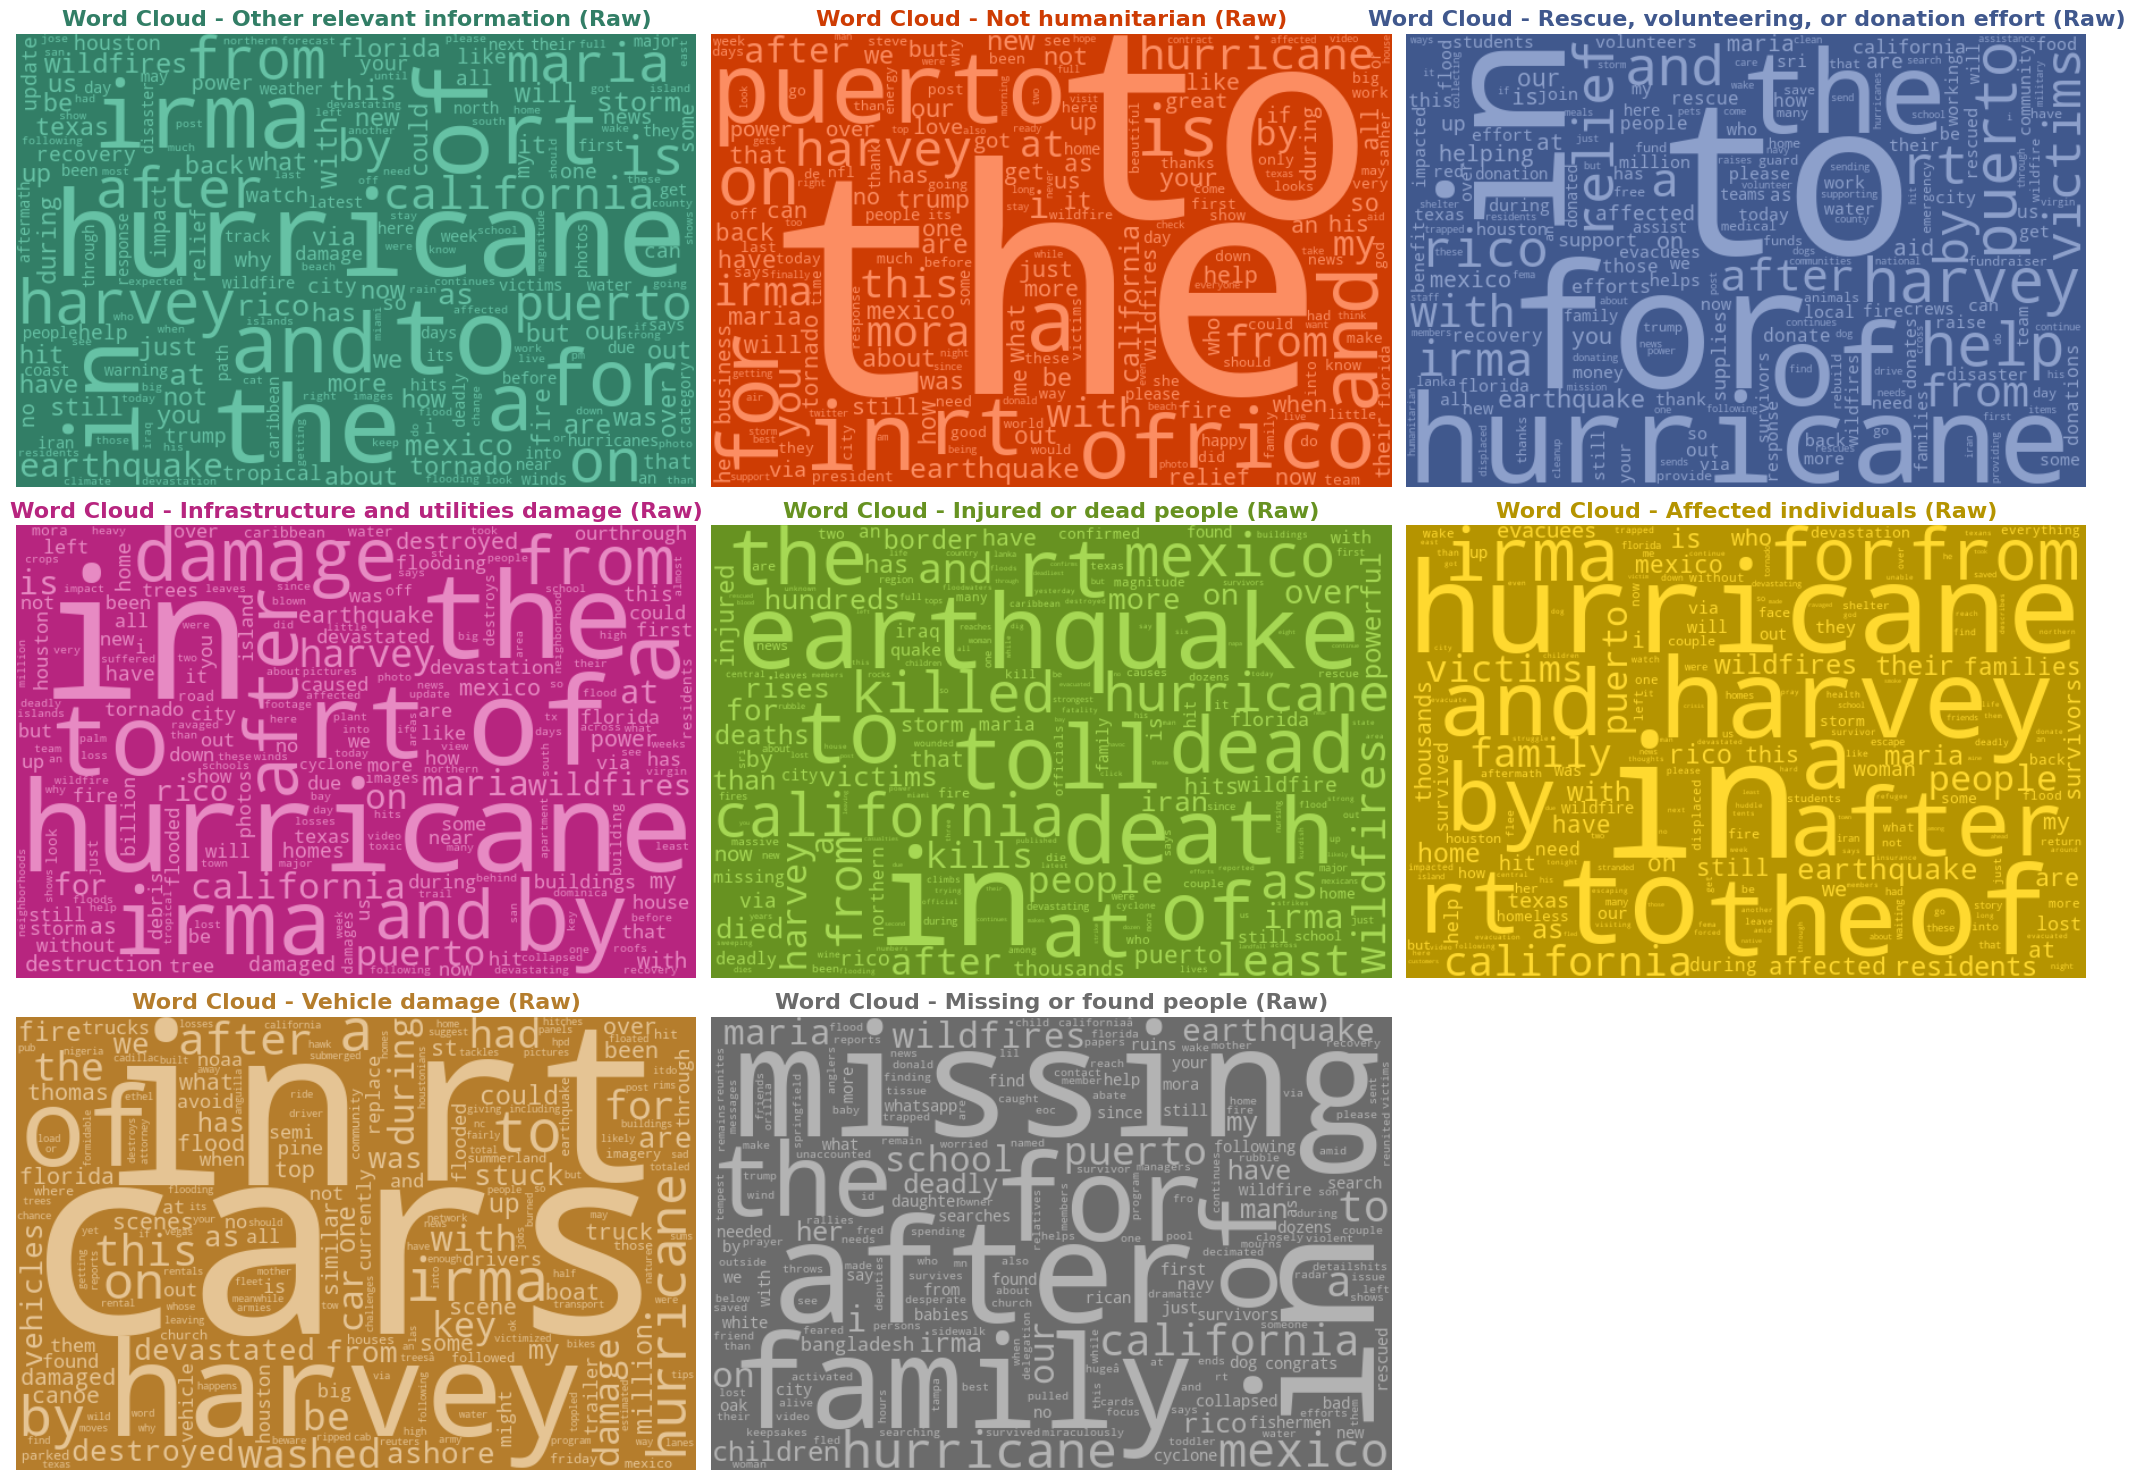

In [15]:
n_cols = 3
n_rows = math.ceil(len(class_order) / n_cols)
fig_wc_human, axes_wc_human = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 5))
axes_wc_human = axes_wc_human.flatten()

for idx, cls in enumerate(class_order):
    texts = df[df["text_human"] == cls]["tweet_text"]
    words = " ".join(texts.dropna().astype(str)).split()
    filtered = [w.lower() for w in words if w.isalpha()]
    freq = Counter(filtered)
    color = colors_human[cls][1]
    # Convert RGB tuple to matplotlib hex color
    if isinstance(color, tuple):
        rgb = tuple(float(c) for c in color[:3])
        color_hex = '#%02x%02x%02x' % tuple(int(255 * c) for c in rgb)
        dark_rgb = darken_color(rgb)
        bg_hex = '#%02x%02x%02x' % tuple(int(255 * c) for c in dark_rgb)
    else:
        color_hex = color
        bg_hex = color  # fallback

    wc = WordCloud(
        width=600,
        height=400,
        background_color=bg_hex,
        colormap=None,
        color_func=lambda *args, **kwargs: color_hex
    )
    wc.generate_from_frequencies(freq)
    axes_wc_human[idx].imshow(wc, interpolation='bilinear')
    axes_wc_human[idx].set_title(
        f'Word Cloud - {class_name_map.get(cls, cls)} (Raw)',
        fontsize=16,
        fontweight='bold',
        color=bg_hex
    )
    axes_wc_human[idx].axis('off')

# Remove unused axes
for j in range(len(class_order), len(axes_wc_human)):
    fig_wc_human.delaxes(axes_wc_human[j])

plt.tight_layout()
output_path = os.path.join(images_dir, "task-2_raw_wordclouds.png")
plt.savefig(output_path)
plt.show()

The word clouds above visualize the most frequent words in the tweet texts for each humanitarian class. Larger words indicate higher frequency. 

The color scheme helps distinguish each class, and the background color is a darker shade of the main class color for contrast.

Overall, the word clouds highlight both the shared and unique vocabulary used in tweets across humanitarian categories, but additional text cleaning would improve their interpretability.

## Additional analysis
In this section, we perform additional analyses on the tweet dataset, including emoji usage, part-of-speech (POS) tag distributions, hashtag statistics, and the presence of links. These analyses provide further insights into the linguistic and structural characteristics of informative and not informative tweets, helping to identify features that may distinguish between the two classes.

### Emoji usage

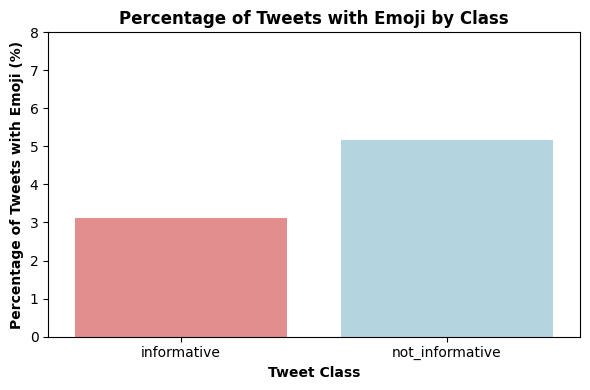

Percentage of tweets with at least one emoji per class:
text_info
informative        3.111630
not_informative    5.165487
Name: emoji_count, dtype: float64


In [16]:
# Function to count emojis in a string
def count_emojis(text):
    if not isinstance(text, str):
        return 0
    return len([char for char in text if char in emoji.EMOJI_DATA])

# Apply to each tweet
df["emoji_count"] = df["tweet_text"].apply(count_emojis)

# Calculate percentage of tweets with at least one emoji per class
emoji_pct = df.groupby("text_info")["emoji_count"].apply(lambda x: (x > 0).mean() * 100)

plt.figure(figsize=(6, 4))
sns.barplot(x=emoji_pct.index, y=emoji_pct.values, palette=["lightcoral", "lightblue"])
plt.title("Percentage of Tweets with Emoji by Class", fontweight='bold')
plt.xlabel("Tweet Class", fontweight='bold')
plt.ylabel("Percentage of Tweets with Emoji (%)", fontweight='bold')
plt.ylim(0, 8)

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "text_task-1_emoji_presence.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

print("Percentage of tweets with at least one emoji per class:")
print(emoji_pct)


The barplot above shows the percentage of tweet containing at least one emoji for each class ("informative" and "not informative").

The plot suggest that emoji appears slightly more in "not informative" tweets.

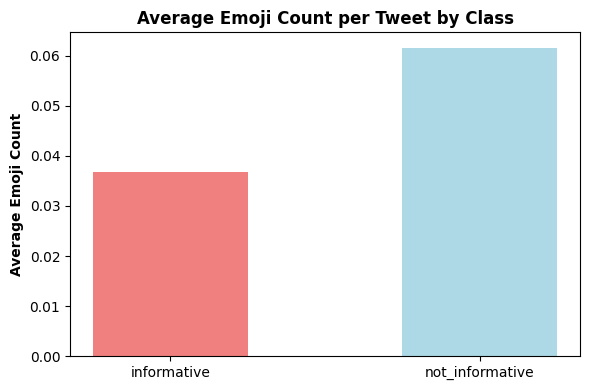

Average emojis per tweet (informative): 0.0367
Average emojis per tweet (not_informative): 0.0616


In [17]:
# Compute average emoji use per tweet by class
emoji_stats = {
    "informative": df[df["text_info"] == "informative"]["emoji_count"].mean(),
    "not_informative": df[df["text_info"] == "not_informative"]["emoji_count"].mean(),
}

plt.figure(figsize=(6, 4))
plt.bar(emoji_stats.keys(), emoji_stats.values(), width=0.5, color=["lightcoral", "lightblue"])
plt.title("Average Emoji Count per Tweet by Class", fontweight='bold')
plt.ylabel("Average Emoji Count", fontweight='bold')

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "text_task-1_avg_emoji_per_tweet.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

# Print results
for k, v in emoji_stats.items():
    print(f"Average emojis per tweet ({k}): {v:.4f}")


The barplot above shows the average number of emojis per tweet for each class ("informative" and "not informative"). Both classes have a low average emoji usage, with "not informative" tweets containing slightly more emojis on average than "informative" tweets.

This suggests that while emojis are not common in either class, they are used a bit more frequently in tweets that are not informative.

Overall, emoji usage is not a prominent feature in this dataset and may have limited value for distinguishing between the two classes.

### POS tagging

In [18]:
spacy.cli.download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [19]:
# Unique texts to avoid redundant processing
unique_texts = df["tweet_text"].dropna().unique()

# POS tag mapping
pos_map = {}

for doc in tqdm(nlp.pipe(unique_texts, batch_size=50), total=len(unique_texts), desc="Extracting POS tags"):
    pos_tags = [token.pos_ for token in doc]
    pos_map[doc.text] = Counter(pos_tags)

# Map POS counters back to original dataframe
df["pos_tags"] = df["tweet_text"].map(pos_map)

Extracting POS tags: 100%|██████████| 16058/16058 [00:57<00:00, 277.50it/s]


In [20]:
def aggregate_pos(subset):
    all_tags = subset["pos_tags"].dropna().tolist()
    return sum(all_tags, Counter())

# Compute aggregate POS tag frequencies
pos_overall = aggregate_pos(df)
pos_info = aggregate_pos(df[df["text_info"] == "informative"])
pos_not_info = aggregate_pos(df[df["text_info"] == "not_informative"])

# Display most common POS tags
print("Top POS (Overall):", pos_overall.most_common(5))
print("Top POS (Informative):", pos_info.most_common(5))
print("Top POS (Not Informative):", pos_not_info.most_common(5))

Top POS (Overall): [('PROPN', 83633), ('NOUN', 56993), ('PUNCT', 29302), ('ADP', 26777), ('VERB', 26445)]
Top POS (Informative): [('PROPN', 59056), ('NOUN', 42143), ('ADP', 20123), ('PUNCT', 20071), ('VERB', 19503)]
Top POS (Not Informative): [('PROPN', 24577), ('NOUN', 14850), ('PUNCT', 9231), ('VERB', 6942), ('ADP', 6654)]


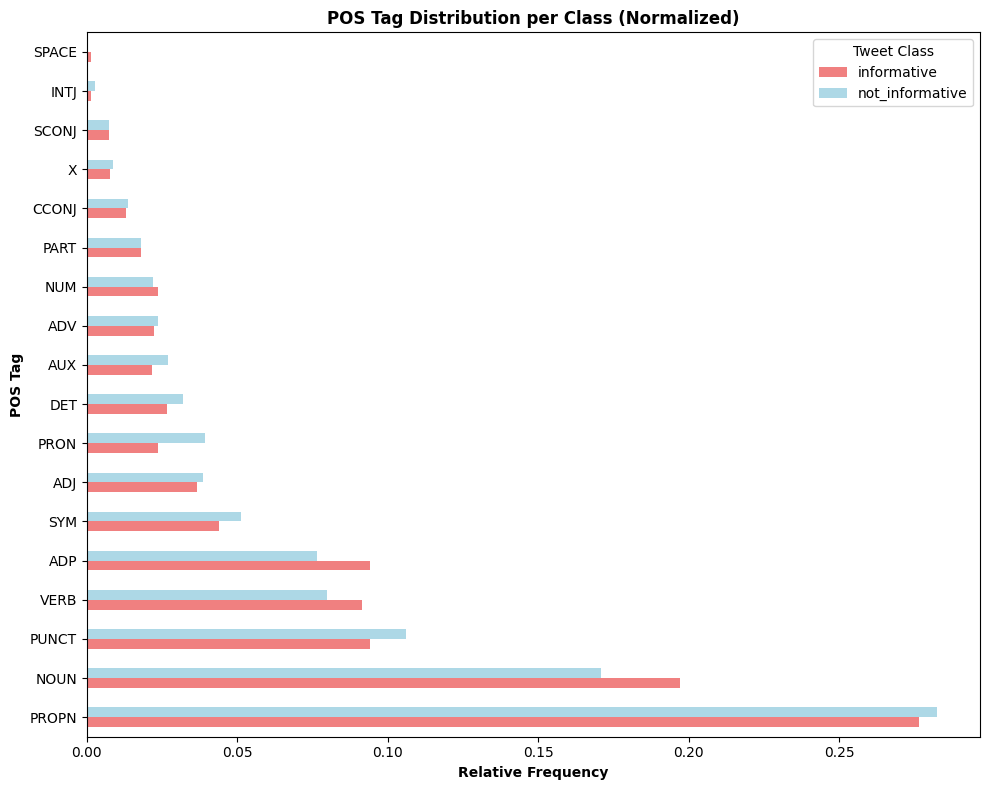

In [21]:
# Convert Counter objects to DataFrames for plotting
def counter_to_df(counter, class_name):
    df = pd.DataFrame(counter.items(), columns=["POS", "Count"])
    df["Class"] = class_name
    total = df["Count"].sum()
    df["Frequency"] = df["Count"] / total  # normalize
    return df

df_info = counter_to_df(pos_info, "informative")
df_not_info = counter_to_df(pos_not_info, "not_informative")

# Combine both classes
df_pos = pd.concat([df_info, df_not_info], ignore_index=True)

# Pivot for grouped bar plot
pivot = df_pos.pivot(index="POS", columns="Class", values="Frequency").fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]  # sort by total frequency

# Plot
pivot.plot(kind="barh", figsize=(10, 8), color=["lightcoral", "lightblue"])
plt.title("POS Tag Distribution per Class (Normalized)", fontweight='bold')
plt.xlabel("Relative Frequency", fontweight='bold')
plt.ylabel("POS Tag", fontweight='bold')
plt.legend(title="Tweet Class")

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "text_task-1_pos_tag_distribution.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

The plot above shows the distribution of part-of-speech (POS) tags in informative and not informative tweets, normalized by total tag count for each class. Each horizontal bar represents the relative frequency of a specific POS tag (e.g., PROPN for proper nouns, NOUN, VERB, etc.) in each class.

The main POS tags (Universal POS tagset) and their meanings are:

- **PROPN**: Proper noun (e.g., California, Harvey)
- **NOUN**: Noun (e.g., fire, people)
- **PUNCT**: Punctuation (e.g., ., !, ?)
- **VERB**: Verb (e.g., help, destroy)
- **ADP**: Adposition (prepositions and postpositions, e.g., in, on, by)
- **SYM**: Symbol (e.g., #, @, $)
- **ADJ**: Adjective (e.g., new, deadly)
- **PRON**: Pronoun (e.g., he, it, you)
- **DET**: Determiner (e.g., the, a, some)
- **AUX**: Auxiliary verb (e.g., is, have, will)
- **ADV**: Adverb (e.g., now, still)
- **NUM**: Numeral (e.g., 10, first)
- **PART**: Particle (e.g., to, not, 's)
- **CCONJ**: Coordinating conjunction (e.g., and, or, but)
- **X**: Other (foreign words, typos, etc.)
- **SCONJ**: Subordinating conjunction (e.g., because, if)
- **INTJ**: Interjection (e.g., wow, oh)
- **SPACE**: Space (whitespace)

Key observations:
- Proper nouns (PROPN) and common nouns (NOUN) are the most frequent tags in both classes, reflecting the prevalence of named entities and objects in crisis-related tweets.
- Informative tweets have a slightly higher proportion of NOUN and VERB tags, suggesting more descriptive and action-oriented language.
- Not informative tweets show a higher proportion of pronouns (PRON) and punctuation (PUNCT), indicating more conversational or less content-rich text.
- The overall POS distribution is similar between classes, but subtle differences may help distinguish informative content.

This analysis highlights linguistic patterns that could be useful for feature engineering in tweet classification tasks.

### Hashtags usage

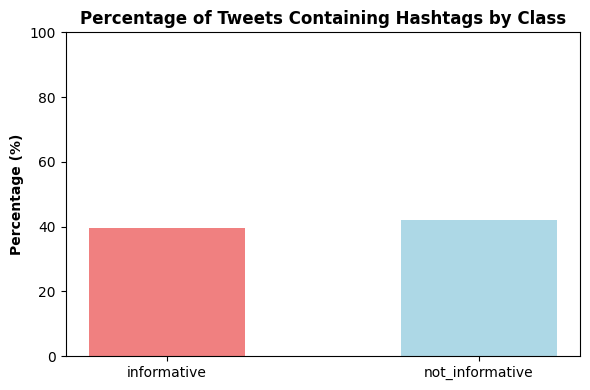

Percentage of tweets with hashtags (informative): 39.67%
Percentage of tweets with hashtags (not_informative): 42.15%


In [22]:
# Extract hashtags using regex
def extract_hashtags(text):
    if not isinstance(text, str):
        return []
    return re.findall(r"#\w+", text.lower())  # lowercase for consistency

# Apply to full DataFrame
df["hashtags"] = df["tweet_text"].apply(extract_hashtags)

# Calculate percentage of tweets containing at least one hashtag per class
def pct_with_hashtag(subset):
	return (subset["hashtags"].apply(lambda x: len(x) > 0).mean()) * 100

pct_hashtag_info = pct_with_hashtag(df[df["text_info"] == "informative"])
pct_hashtag_not_info = pct_with_hashtag(df[df["text_info"] == "not_informative"])

pct_hashtag_stats = {
	"informative": pct_hashtag_info,
	"not_informative": pct_hashtag_not_info
}

plt.figure(figsize=(6, 4))
bars = plt.bar(pct_hashtag_stats.keys(), pct_hashtag_stats.values(), width=0.5, color=["lightcoral", "lightblue"])
plt.title("Percentage of Tweets Containing Hashtags by Class", fontweight='bold')
plt.ylabel("Percentage (%)", fontweight='bold')
plt.ylim(0, 100)

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "text_task-1_hashtags_percentage.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

for k, v in pct_hashtag_stats.items():
	print(f"Percentage of tweets with hashtags ({k}): {v:.2f}%")

The barplot above compares the percentage of tweets containing at least one hashtag between the "informative" and "not informative" classes. Both classes have a similar proportion of tweets with hashtags, with "not informative" tweets showing a slightly higher percentage (~42%) compared to "informative" tweets (~40%). This suggests that hashtag usage is common in both types of tweets and does not strongly differentiate between informative and not informative content in this dataset.

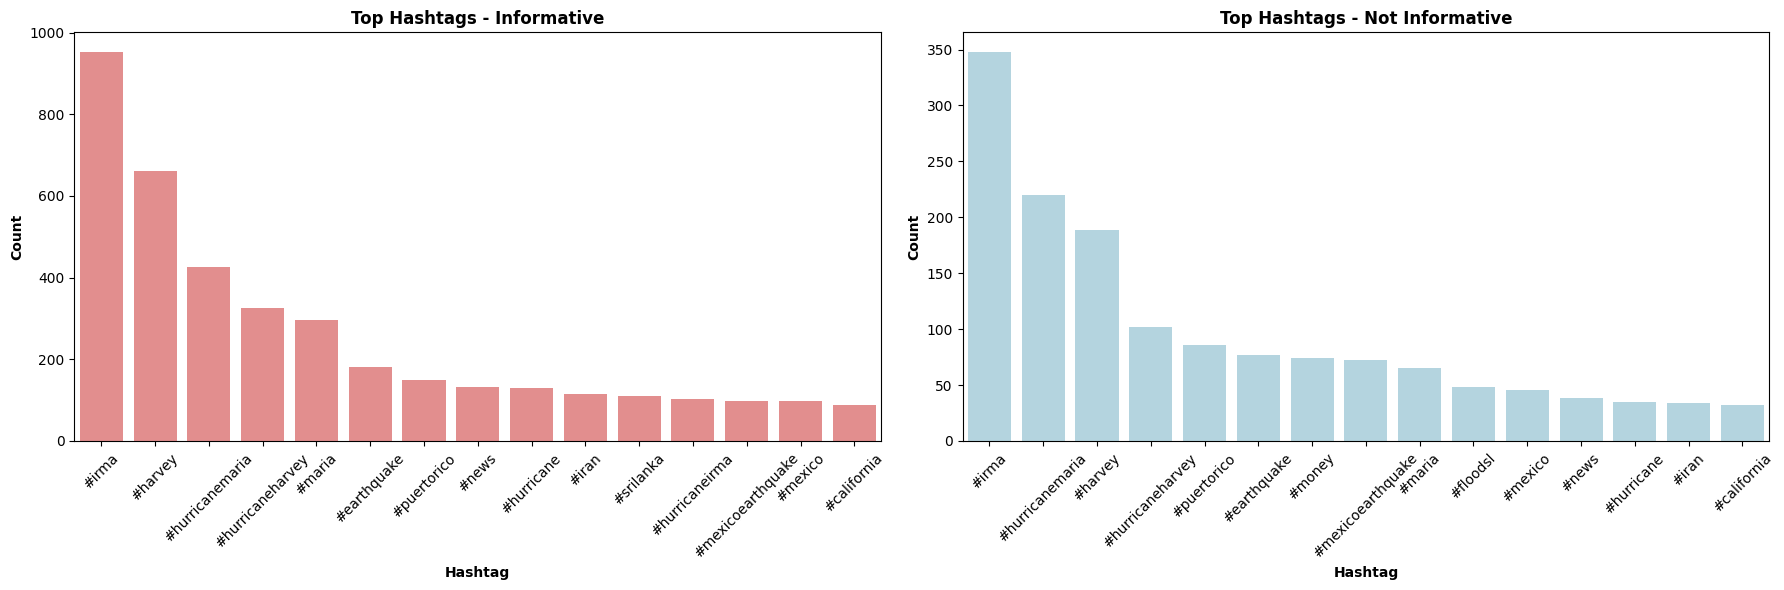

In [23]:
# Count top hashtags in each class
def get_top_hashtags(subset, n=15):
    all_hashtags = sum(subset["hashtags"].tolist(), [])
    return Counter(all_hashtags).most_common(n)

hashtags_info = get_top_hashtags(df[df["text_info"] == "informative"])
hashtags_not_info = get_top_hashtags(df[df["text_info"] == "not_informative"])

# Convert to DataFrames
df_hash_info = pd.DataFrame(hashtags_info, columns=["hashtag", "count"])
df_hash_not_info = pd.DataFrame(hashtags_not_info, columns=["hashtag", "count"])

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)  # 1 row, 2 columns

# Informative hashtags
sns.barplot(data=df_hash_info, x="hashtag", y="count", ax=axes[0], color="lightcoral")
axes[0].set_title("Top Hashtags - Informative", fontweight='bold')
axes[0].set_ylabel("Count", fontweight='bold')
axes[0].set_xlabel("Hashtag", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Not informative hashtags
sns.barplot(data=df_hash_not_info, x="hashtag", y="count", ax=axes[1], color="lightblue")
axes[1].set_title("Top Hashtags - Not Informative", fontweight='bold')
axes[1].set_ylabel("Count", fontweight='bold')
axes[1].set_xlabel("Hashtag", fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "text_task-1_top_hashtags.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

The barplots above compare the top 15 most frequent hashtags used in "informative" and "not informative" tweets. 

There is significant overlap in popular hashtags between the two classes, with disaster-related tags like `#irma`, `#harvey`, `#hurricanemaria`, `#hurricaneharvey`, and `#puertorico` appearing in both.

Some hashtags are more prominent in one class than the other. For example, `#news` and `#hurricaneirma` are more frequent in informative tweets, while hashtags like `#money` and `#floodsl` appear more in not informative tweets.

These plots suggest that while hashtag usage patterns are similar across classes, certain hashtags may be more indicative of informative content. However, the overlap also indicates that hashtags alone may not be sufficient to distinguish between informative and not informative tweets.

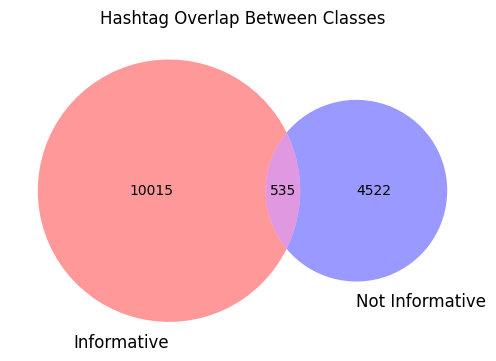

In [24]:
# Compute sets of hashtags for each class by exploding the lists of hashtags in the DataFrame
hashtags_info_set = set(df[df["text_info"] == "informative"]["hashtags"].explode())
hashtags_not_info_set = set(df[df["text_info"] == "not_informative"]["hashtags"].explode())

# Plot a Venn diagram to visualize the overlap between hashtags used in informative and not informative tweets
plt.figure(figsize=(6, 6))
venn2(
    [hashtags_info_set, hashtags_not_info_set],
    set_labels=('Informative', 'Not Informative'),
    set_colors=('red', 'blue')
)

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "text_task-1_hashtags_overlap.png")
plt.savefig(output_path)

plt.title("Hashtag Overlap Between Classes")
plt.show()

The Venn diagram above visualizes the overlap between hashtags used in "informative" and "not informative" tweets. The two circles represent the sets of unique hashtags from each class:

- The intersection (overlapping area) shows hashtags that appear in both informative and not informative tweets, indicating common topics or events discussed across both classes.
- The non-overlapping areas represent hashtags unique to each class. These unique hashtags may reflect topics, campaigns, or discussions specific to either informative or not informative tweets.

Overall, the diagram demonstrates that while there is substantial overlap in hashtag usage between the two classes, each class also contains a notable set of unique hashtags. This suggests that some hashtags are broadly used regardless of informativeness, while others may be more class-specific and could help differentiate tweet types.

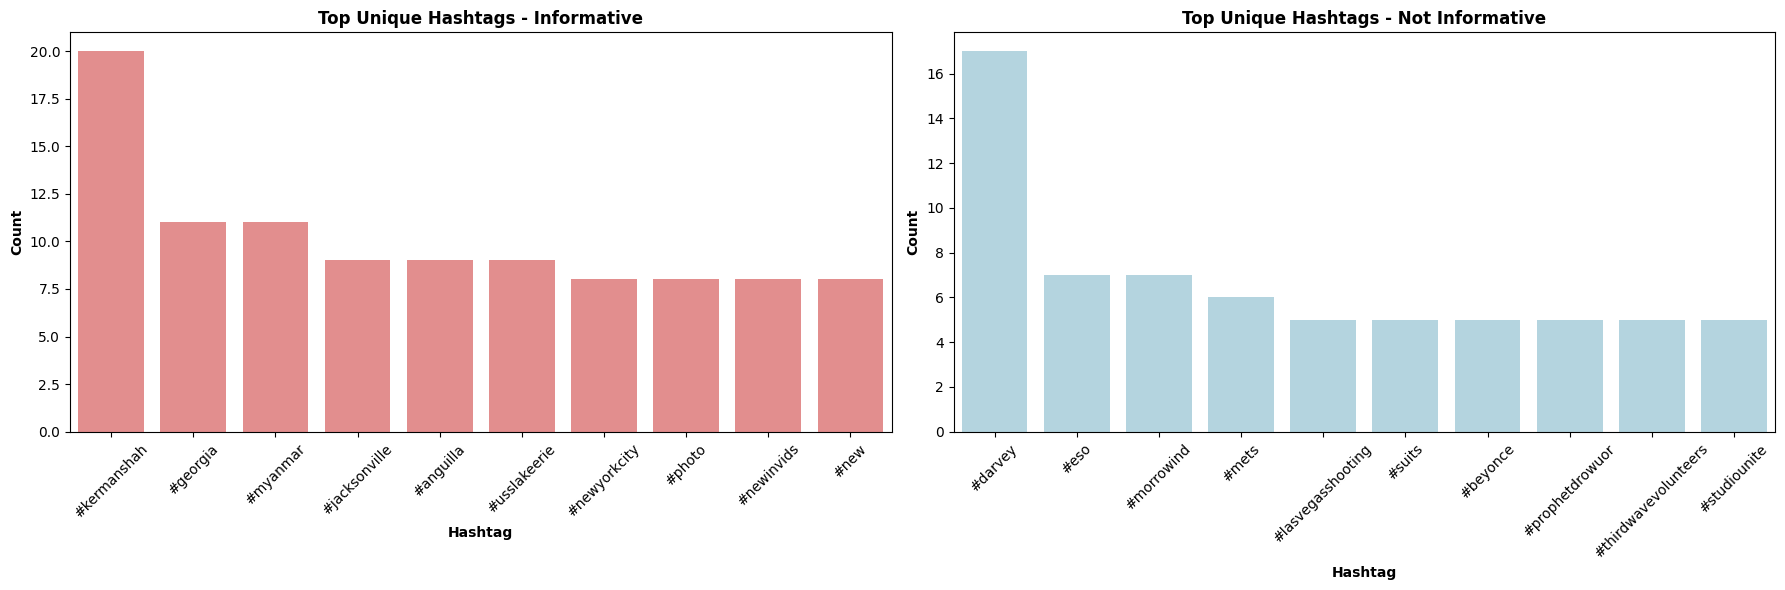

In [25]:
# Extract hashtags unique to each class
unique_info_hashtags = hashtags_info_set.difference(hashtags_not_info_set)
unique_not_info_hashtags = hashtags_not_info_set.difference(hashtags_info_set)

# Get counts for unique hashtags only, then take top 10
unique_info_counts = [(h, c) for h, c in Counter(sum(df[df["text_info"] == "informative"]["hashtags"].tolist(), [])).items() if h in unique_info_hashtags]
unique_not_info_counts = [(h, c) for h, c in Counter(sum(df[df["text_info"] == "not_informative"]["hashtags"].tolist(), [])).items() if h in unique_not_info_hashtags]

# Sort by count and take top 10
top_unique_info = sorted(unique_info_counts, key=lambda x: x[1], reverse=True)[:10]
top_unique_not_info = sorted(unique_not_info_counts, key=lambda x: x[1], reverse=True)[:10]

# Convert to DataFrames
df_top_unique_info = pd.DataFrame(top_unique_info, columns=["hashtag", "count"])
df_top_unique_not_info = pd.DataFrame(top_unique_not_info, columns=["hashtag", "count"])

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)  # 1 row, 2 columns

# Informative unique hashtags
sns.barplot(data=df_top_unique_info, x="hashtag", y="count", ax=axes[0], color="lightcoral")
axes[0].set_title("Top Unique Hashtags - Informative", fontweight='bold')
axes[0].set_ylabel("Count", fontweight='bold')
axes[0].set_xlabel("Hashtag", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Not informative unique hashtags
sns.barplot(data=df_top_unique_not_info, x="hashtag", y="count", ax=axes[1], color="lightblue")
axes[1].set_title("Top Unique Hashtags - Not Informative", fontweight='bold')
axes[1].set_ylabel("Count", fontweight='bold')
axes[1].set_xlabel("Hashtag", fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "text_task-1_top_not_shared_hashtags.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

The barplots above display the top 10 unique hashtags belonging to each class: "informative" (left) and "not informative" (right). Each bar represents a hashtag that appears exclusively in one class and not the other, with its height indicating the frequency of occurrence.

The most frequent unique hashtags in "informative" tweets (e.g., `#kermanshah`, `#georgia`, `#myanmar`) often relate to specific locations or events, suggesting these tweets provide targeted crisis information.

Unique hashtags in "not informative" tweets (e.g., `#darvey`, `#eso`, `#morrowind`) are more varied and sometimes unrelated to crisis events, reflecting broader or less relevant discussions.
 
While there is substantial overlap in hashtag usage between classes, each class also contains distinct hashtags. These unique hashtags may help identify class-specific topics or communities, but their relatively low frequency suggests they are less central to the overall conversation.

### Link usage

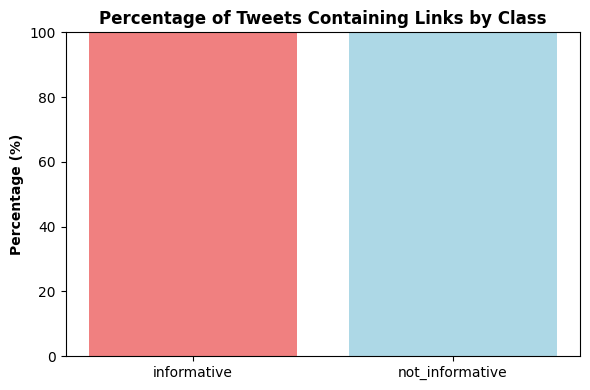

Percentage of tweets with links (informative): 100.00%
Percentage of tweets with links (not_informative): 99.98%


In [26]:
# Function to check if a tweet contains a link (http/https)
def contains_link(text):
	if not isinstance(text, str):
		return False
	return bool(re.search(r"http[s]?://", text))

# Add a column for link presence
df["has_link"] = df["tweet_text"].apply(contains_link)

# Calculate percentage of tweets with links per class
pct_link_info = df[df["text_info"] == "informative"]["has_link"].mean() * 100
pct_link_not_info = df[df["text_info"] == "not_informative"]["has_link"].mean() * 100

pct_link_stats = {
	"informative": pct_link_info,
	"not_informative": pct_link_not_info,
}

plt.figure(figsize=(6, 4))
plt.bar(pct_link_stats.keys(), pct_link_stats.values(), color=["lightcoral", "lightblue"])
plt.title("Percentage of Tweets Containing Links by Class", fontweight='bold')
plt.ylabel("Percentage (%)", fontweight='bold')
plt.ylim(0, 100)

# Save the current figure to the images directory
output_path = os.path.join(images_dir, "text_task-1_links_percentage.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

for k, v in pct_link_stats.items():
	print(f"Percentage of tweets with links ({k}): {v:.2f}%")

The barplot above compares the percentage of tweets containing links between the "informative" and "not informative" classes. Both classes have an extremely high proportion of tweets with links: nearly 100% for both. This indicates that the presence of links is a common feature in the dataset and does not differentiate between informative and not informative tweets. Including links is likely standard practice in crisis-related tweets, regardless of their informativeness.